**U.S. Foreign Aid Annual Spend for Ethiopia**

Data was obtained from ForeignAssistance.gov (https://foreignassistance.gov), associated with the U.S. State Department.

In [70]:
import pandas as pd

df = pd.read_csv('results.csv')
df.shape


(3173, 51)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 51 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Country ID                              3173 non-null   int64 
 1   Country Code                            3173 non-null   object
 2   Country Name                            3173 non-null   object
 3   Region ID                               3173 non-null   int64 
 4   Region Name                             3173 non-null   object
 5   Income Group ID                         3173 non-null   int64 
 6   Income Group Name                       3173 non-null   object
 7   Income Group Acronym                    3173 non-null   object
 8   Managing Agency ID                      3173 non-null   int64 
 9   Managing Agency Acronym                 3173 non-null   object
 10  Managing Agency Name                    3173 non-null   object
 11  Mana

In [72]:
usaid_df = df[df['Managing Agency Acronym'] == 'USAID']
usaid_df.shape

(2726, 51)

In [73]:
# Limiting data by entries where USAID was the Managing Agency, and excluded influenza and "other" health threats. The data does include funding for general healtcare infrastructure, which isn't necessarily limited to the 3 diseases of interest: HIV/AIDS, malaria and TB.
usaid_df = df[(df['Managing Agency Acronym'] == 'USAID') & (df['US Sector Name'] != 'Other Public Health Threats') & (df['US Sector Name'] != 'Pandemic Influenza and Other Emerging Threats (PIOET)')]
usaid_df.shape

(2415, 51)

In [74]:
usaid_df.dtypes

Country ID                                 int64
Country Code                              object
Country Name                              object
Region ID                                  int64
Region Name                               object
Income Group ID                            int64
Income Group Name                         object
Income Group Acronym                      object
Managing Agency ID                         int64
Managing Agency Acronym                   object
Managing Agency Name                      object
Managing Sub-agency or Bureau ID           int64
Managing Sub-agency or Bureau Acronym     object
Managing Sub-agency or Bureau Name        object
Implementing Partner Category ID           int64
Implementing Partner Category Name        object
Implementing Partner Sub-category ID      object
Implementing Partner Sub-category Name     int64
Implementing Partner ID                    int64
Implementing Partner Name                 object
International Catego

In [75]:
df_columns = usaid_df[['Fiscal Year', 'Current Dollar Amount']]

In [76]:
#Converting Dollar Amount for Readability on Line Plot
df_columns['Current Dollar Amount'] = df_columns['Current Dollar Amount']/1000000

C:\Users\tlett\AppData\Local\Temp\ipykernel_33640\296915851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_columns['Current Dollar Amount'] = df_columns['Current Dollar Amount']/1000000


In [77]:
df_columns.describe()

,Fiscal Year,Current Dollar Amount
count,2415.000000,2415.000000
mean,2011.684886,0.910064
std,4.915660,2.386034
min,2001.000000,-5.017237
25%,2008.000000,0.002587
50%,2011.000000,0.114961
75%,2016.000000,0.771250
max,2021.000000,45.505316


In [78]:
df_group = df_columns.groupby('Fiscal Year', as_index=False).sum()
df_group

,Fiscal Year,Current Dollar Amount
0,2001,5.231653
1,2002,12.449080
2,2003,21.871108
3,2004,34.964624
4,2005,46.319730
5,2006,54.897661
6,2007,63.419838
7,2008,123.238527
8,2009,161.924491
9,2010,96.488232


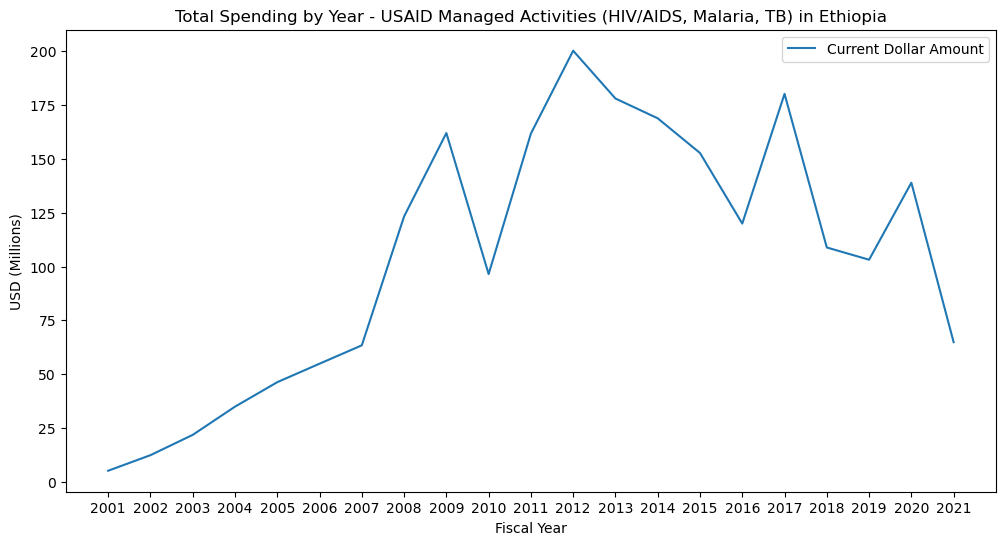

In [79]:
import matplotlib.pyplot as plt
df_group.plot.line(x='Fiscal Year', y='Current Dollar Amount', ylabel = 'USD (Millions)', title='Total Spending by Year - USAID Managed Activities (HIV/AIDS, Malaria, TB) in Ethiopia', xticks=df_group['Fiscal Year'], figsize = (12,6))
plt.show()


**Child Mortality Data**

Data was obtained from the UN Inter-agency Group for Child Mortality Estimation (https://childmortality.org/). Data was extracted for Ethiopia mortality, ages 5 and under, for 3 major diseases: HIV/AIDS, malaria and tuberculosis. 

In [82]:
df2 = pd.read_csv('UNICEF-CME_CAUSE_OF_DEATH-1.0-download.csv')
df2.shape

(66, 11)

In [83]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geographic area  66 non-null     object 
 1   Indicator        66 non-null     object 
 2   Cause of death   66 non-null     object 
 3   Sex              66 non-null     object 
 4   Age group        66 non-null     object 
 5   SERIES_NAME      66 non-null     object 
 6   Unit of measure  66 non-null     object 
 7   TIME_PERIOD      66 non-null     int64  
 8   OBS_VALUE        66 non-null     float64
 9   LOWER_BOUND      66 non-null     float64
 10  UPPER_BOUND      66 non-null     float64
dtypes: float64(3), int64(1), object(7)
memory usage: 5.8+ KB


In [84]:
unique_years = df2['TIME_PERIOD'].unique()
unique_years

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype=int64)

In [85]:
deaths_df = df2[(df2['TIME_PERIOD'] != 2000)]
deaths_df.shape

(63, 11)

In [86]:
deaths_df.describe()

,TIME_PERIOD,OBS_VALUE,LOWER_BOUND,UPPER_BOUND
count,63.000000,63.000000,63.000000,63.000000
mean,2011.000000,5374.597242,2661.476190,12702.857143
std,6.103938,4049.584037,2875.672409,7967.940890
min,2001.000000,1297.157492,0.000000,1560.000000
25%,2006.000000,1984.060139,0.000000,6830.000000
50%,2011.000000,3583.904114,1520.000000,12200.000000
75%,2016.000000,8278.339646,4330.000000,18650.000000
max,2021.000000,14118.000000,10400.000000,35200.000000


In [87]:
df_columns2 = deaths_df[['TIME_PERIOD', 'OBS_VALUE']]

In [88]:
# Combining causes of death for 3 diseases by year

df_group_deaths = df_columns2.groupby('TIME_PERIOD', as_index=False).sum()
df_group_deaths

,TIME_PERIOD,OBS_VALUE
0,2001,31317.713574
1,2002,28599.222593
2,2003,28376.216964
3,2004,27976.491974
4,2005,21581.094635
5,2006,19364.279816
6,2007,16800.012970
7,2008,14410.713135
8,2009,15955.665367
9,2010,16482.688721


In [89]:
df_group_deaths.describe()

,TIME_PERIOD,OBS_VALUE
count,21.000000,21.000000
mean,2011.000000,16123.791726
std,6.204837,8120.252282
min,2001.000000,4609.388344
25%,2006.000000,10185.509409
50%,2011.000000,15955.665367
75%,2016.000000,19364.279816
max,2021.000000,31317.713574


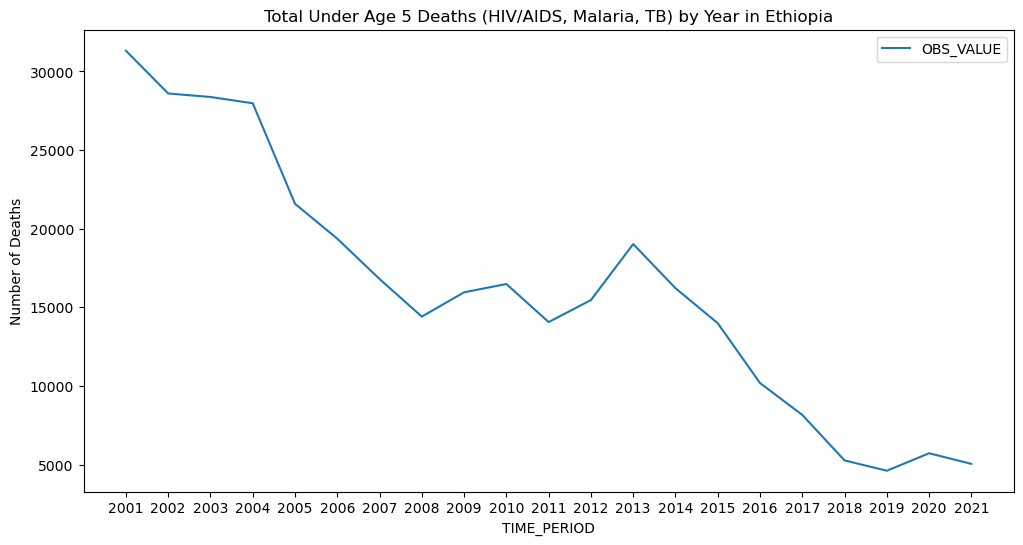

In [90]:
df_group_deaths.plot.line(x='TIME_PERIOD', y='OBS_VALUE', ylabel = 'Number of Deaths', title='Total Under Age 5 Deaths (HIV/AIDS, Malaria, TB) by Year in Ethiopia', xticks=df_group_deaths['TIME_PERIOD'],figsize = (12,6))
plt.show()

In [91]:
df_joined = df_group.join(df_group_deaths)

In [92]:
#Converting Dollar Amount back to Raw Value
df_joined['Current Dollar Amount'] = df_joined['Current Dollar Amount']*1000000
df_joined

,Fiscal Year,Current Dollar Amount,TIME_PERIOD,OBS_VALUE
0,2001,5231653.0,2001,31317.713574
1,2002,12449080.0,2002,28599.222593
2,2003,21871108.0,2003,28376.216964
3,2004,34964624.0,2004,27976.491974
4,2005,46319730.0,2005,21581.094635
5,2006,54897661.0,2006,19364.279816
6,2007,63419838.0,2007,16800.012970
7,2008,123238527.0,2008,14410.713135
8,2009,161924491.0,2009,15955.665367
9,2010,96488232.0,2010,16482.688721


In [93]:
df_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fiscal Year            21 non-null     int64  
 1   Current Dollar Amount  21 non-null     float64
 2   TIME_PERIOD            21 non-null     int64  
 3   OBS_VALUE              21 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 804.0 bytes


**Regression Plot Non-Normalized**

<Axes: xlabel='Current Dollar Amount', ylabel='OBS_VALUE'>

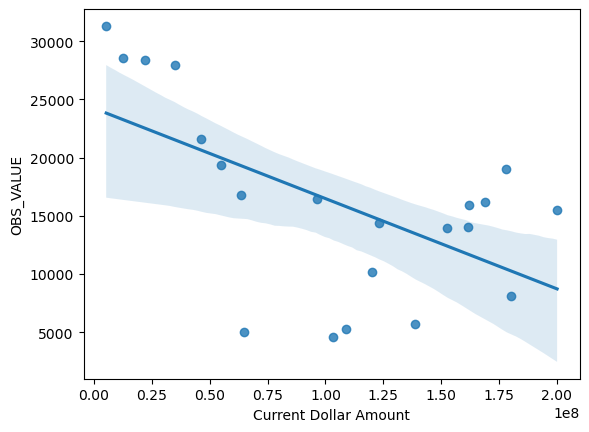

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

sns.regplot(x="Current Dollar Amount", y="OBS_VALUE", data=df_joined)

In [96]:
#Calculating Correlation
df_joined[['Current Dollar Amount', 'OBS_VALUE']].corr()

,Current Dollar Amount,OBS_VALUE
Current Dollar Amount,1.000000,-0.581505
OBS_VALUE,-0.581505,1.000000


In [97]:
#Commenting out Normalization
#df_joined['Current Dollar Amount'] = df_joined['Current Dollar Amount']/df_joined['Current Dollar Amount'].max()
df_joined.head()

,Fiscal Year,Current Dollar Amount,TIME_PERIOD,OBS_VALUE
0,2001,5231653.0,2001,31317.713574
1,2002,12449080.0,2002,28599.222593
2,2003,21871108.0,2003,28376.216964
3,2004,34964624.0,2004,27976.491974
4,2005,46319730.0,2005,21581.094635


**Fitting Linear Regression with Non-Normalized Dollar Amount**

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lm = LinearRegression()
X = df_joined[['Current Dollar Amount']]
Y = df_joined['OBS_VALUE']
lm.fit(X,Y)
Yhat = lm.predict(X)
mse = mean_squared_error(df_joined['OBS_VALUE'], Yhat)
r2 = lm.score(X,Y)
print(mse)
print(r2)

41563379.86124784
0.33814765633600197


In [100]:
## Add code for predictions with dummy values ##
df_slr = pd.read_csv('slr_dummy.csv')
df_slr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Current Dollar Amount  9 non-null      int64
dtypes: int64(1)
memory usage: 204.0 bytes


In [101]:
df_slr

,Current Dollar Amount
0,1600000000
1,800000000
2,400000000
3,200000000
4,30000000
5,10000000
6,5000000
7,1000000
8,0


In [102]:
x_dummy = df_slr
Yhat_dummy = lm.predict(x_dummy)
Yhat_dummy

array([-99781.20823136, -37772.67951454,  -6768.41515613,   8733.71702307,
        21910.5293754 ,  23460.74259332,  23848.2958978 ,  24158.33854138,
        24235.84920228])

*Residual Plot*

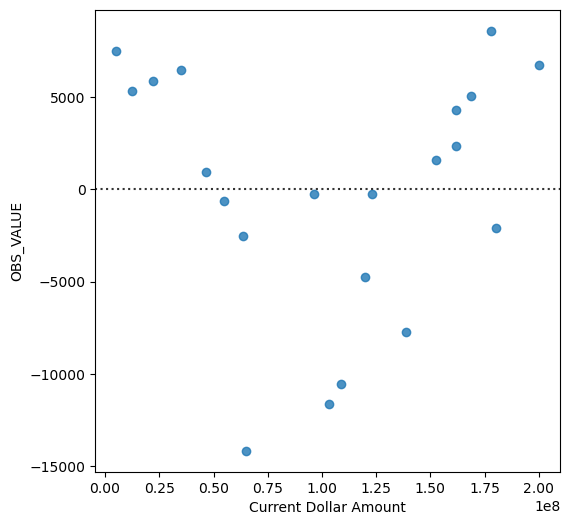

In [104]:
width = 6
height = 6
plt.figure(figsize=(width, height))
sns.residplot(x=df_joined["Current Dollar Amount"], y=df_joined["OBS_VALUE"])
plt.show()

**Fitting Polynomial Models (Non-Normalized Dollar Amount)**

In [106]:
x = df_joined["Current Dollar Amount"]
y = df_joined["OBS_VALUE"]

In [107]:
import numpy as np
f1 = np.polyfit(x, y, 1)
p1 = np.poly1d(f1)

In [108]:
f3 = np.polyfit(x, y, 3)
p3 = np.poly1d(f3)

In [109]:
f5 = np.polyfit(x, y, 5)
p5 = np.poly1d(f5)

In [110]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit for Deaths ~ Dollar Amount')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Deaths')

    plt.show()
    plt.close()

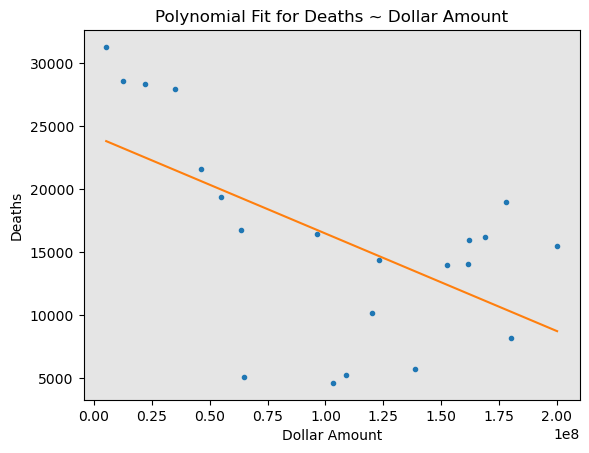

In [111]:
PlotPolly(p1, x, y, 'Dollar Amount')

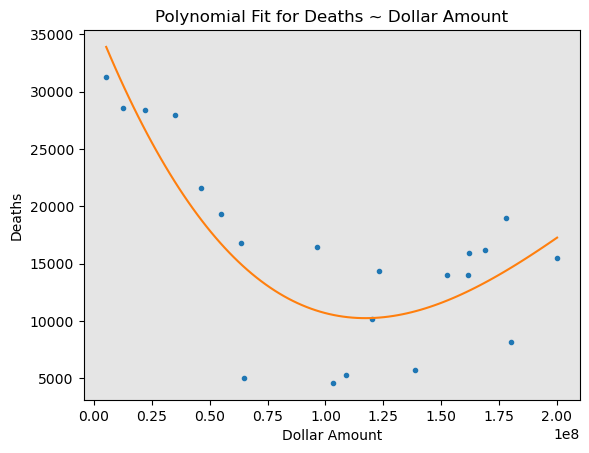

In [112]:
PlotPolly(p3, x, y, 'Dollar Amount')

In [152]:
x_new = np.array([0,300000000,500000000])
y_predicted = np.polyval(f3, x_new)

print("Predictions:", y_predicted)

Predictions: [ 36489.98239423  29708.90116486 -33678.61093584]


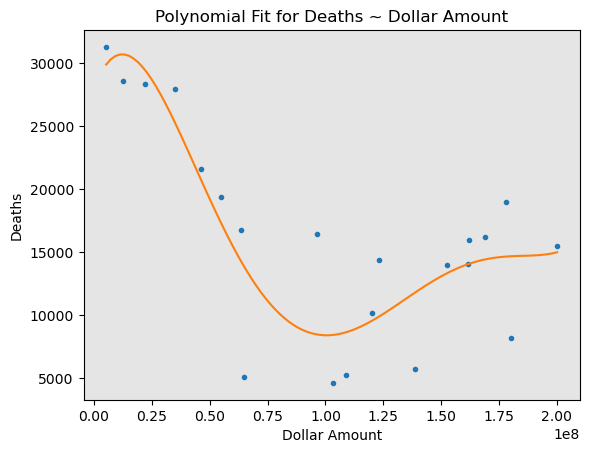

In [113]:
PlotPolly(p5, x, y, 'Dollar Amount')

In [161]:
x_new = np.array([0,15000000,48669403])
y_predicted = np.polyval(f5, x_new)

print("Predictions:", y_predicted)

Predictions: [28046.51418908 30615.81786299 19762.40145135]


In [52]:
r_squared1 = r2_score(y, p1(x))
print("The R-squared value for Degree 1 is:", r_squared1)
mse1 = mean_squared_error(y, p1(x))
print("The MSE for Degree 1 is:", mse1)

r_squared3 = r2_score(y, p3(x))
print("The R-squared value for Degree 3 is:", r_squared3)
mse3 = mean_squared_error(y, p3(x))
print("The MSE for Degree 3 is:", mse3)

r_squared5 = r2_score(y, p5(x))
print("The R-squared value for Degree 5 is:", r_squared5)
mse5 = mean_squared_error(y, p5(x))
print("The MSE for Degree 5 is:", mse5)

The R-squared value for Degree 1 is: 0.33814765633600186
The MSE for Degree 1 is: 41563379.86124784
The R-squared value for Degree 3 is: 0.706121000271444
The MSE for Degree 3 is: 18455180.54879398
The R-squared value for Degree 5 is: 0.7567625800935018
The MSE for Degree 5 is: 15274961.820148882


**Conclusion:** Degree 5 has the highest R-squared value and lowest MSE, making it the optimal model among the 3 options.